# Visual Chart Representations for Cryptocurrency Regime Prediction

**Deep Learning Final Project - Stevens Institute of Technology**

**Dustin M. Haggett**

---

## Research Question

**What visual representation of price data yields the best deep learning model for cryptocurrency regime prediction?**

While traders visually analyze candlestick charts to make decisions, most ML approaches use numerical time series. Recent research shows CNNs can learn from chart images, but no systematic study compares:
- Different image encoding methods (raw charts vs GAF)
- Different visual components (volume, indicators)
- Different architectures (CNN vs Vision Transformer)

## Experiments

1. **Baseline**: Raw candlestick images with simple CNN
2. **Effect of Image Encoding**: Raw charts vs GAF (Gramian Angular Field)
3. **Effect of Chart Components**: Price only → +Volume → +SMA → +Bollinger Bands
4. **Effect of Lookback Window**: 14, 30, 60, 90 days
5. **Effect of Image Resolution**: 64×64, 128×128, 224×224
6. **Effect of Architecture**: Simple CNN → ResNet18 → EfficientNet → ViT
7. **Effect of Transfer Learning**: Random init vs ImageNet pretrained
8. **Generalization Test**: BTC vs ETH vs S&P500

---
## Setup & Imports

In [27]:
pip install yfinance mplfinance pyts timm opencv-python pillow tqdm

Note: you may need to restart the kernel to use updated packages.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf
import mplfinance as mpf
from pyts.image import GramianAngularField

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import timm  # For Vision Transformer and EfficientNet

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from tqdm import tqdm

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Using device: mps


---
## Data Collection

Download historical OHLCV data for BTC, ETH, and S&P500.

In [29]:
def download_data(ticker, start='2018-01-01', end='2024-12-01'):
    """Download OHLCV data from Yahoo Finance."""
    print(f"Downloading {ticker}...")
    df = yf.download(ticker, start=start, end=end, progress=False)
    
    # Handle MultiIndex columns (newer yfinance versions)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df.columns = [c.lower() for c in df.columns]
    df = df[['open', 'high', 'low', 'close', 'volume']]
    df.index.name = 'date'
    print(f"  Downloaded {len(df)} rows from {df.index[0].date()} to {df.index[-1].date()}")
    return df

# Download datasets
data = {
    'BTC': download_data('BTC-USD'),
    'ETH': download_data('ETH-USD'),
    'SPY': download_data('SPY')  # S&P 500 ETF
}

print(f"\nDataset sizes: BTC={len(data['BTC'])}, ETH={len(data['ETH'])}, SPY={len(data['SPY'])}")

  Downloaded 2526 rows from 2018-01-01 to 2024-11-30
  Downloaded 2526 rows from 2018-01-01 to 2024-11-30
  Downloaded 1740 rows from 2018-01-02 to 2024-11-29

Dataset sizes: BTC=2526, ETH=2526, SPY=1740


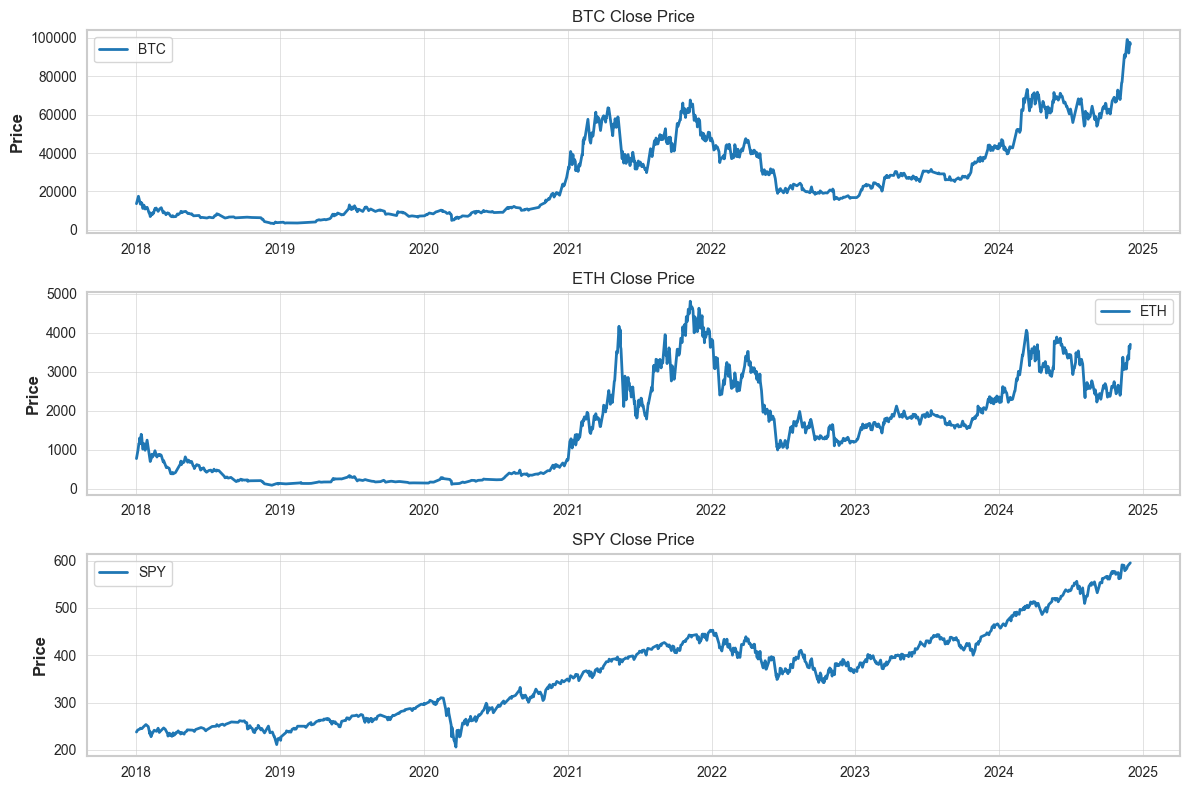

In [30]:
# Quick visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for ax, (name, df) in zip(axes, data.items()):
    ax.plot(df.index, df['close'], label=name)
    ax.set_title(f'{name} Close Price')
    ax.set_ylabel('Price')
    ax.legend()

plt.tight_layout()
plt.savefig('data_overview.png', dpi=150)
plt.show()

---
## Image Generation Functions

We implement multiple methods to convert price data into images:
1. **Raw Candlestick Charts** - Using mplfinance
2. **Gramian Angular Field (GAF)** - Mathematical encoding
3. **Charts with Indicators** - Adding SMA, Bollinger Bands, Volume

In [31]:
class ChartGenerator:
    """Generate various chart image representations from OHLCV data."""
    
    def __init__(self, output_dir='charts', img_size=(224, 224)):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)
        self.img_size = img_size
        
    def generate_candlestick(self, df, filename, 
                              show_volume=False, 
                              show_sma=False,
                              show_bollinger=False,
                              style='charles'):
        """
        Generate candlestick chart image.
        
        Args:
            df: DataFrame with OHLCV data
            filename: Output filename
            show_volume: Add volume subplot
            show_sma: Add SMA lines (7, 25)
            show_bollinger: Add Bollinger Bands
            style: mplfinance style ('charles', 'yahoo', 'nightclouds')
        """
        # Prepare additional plots
        addplots = []
        
        if show_sma:
            sma7 = df['close'].rolling(7).mean()
            sma25 = df['close'].rolling(25).mean()
            addplots.append(mpf.make_addplot(sma7, color='blue', width=0.7))
            addplots.append(mpf.make_addplot(sma25, color='orange', width=0.7))
            
        if show_bollinger:
            sma20 = df['close'].rolling(20).mean()
            std20 = df['close'].rolling(20).std()
            upper = sma20 + 2 * std20
            lower = sma20 - 2 * std20
            addplots.append(mpf.make_addplot(upper, color='gray', width=0.5, linestyle='--'))
            addplots.append(mpf.make_addplot(lower, color='gray', width=0.5, linestyle='--'))
        
        # Create figure
        filepath = self.output_dir / filename
        
        kwargs = {
            'type': 'candle',
            'style': style,
            'volume': show_volume,
            'savefig': dict(fname=filepath, dpi=100, bbox_inches='tight'),
            'axisoff': True,
            'tight_layout': True,
        }
        
        if addplots:
            kwargs['addplot'] = addplots
            
        mpf.plot(df, **kwargs)
        plt.close()
        
        # Resize to target size
        img = Image.open(filepath).convert('RGB')
        img = img.resize(self.img_size, Image.Resampling.LANCZOS)
        img.save(filepath)
        
        return filepath
    
    def generate_gaf(self, prices, filename, method='summation'):
        """
        Generate Gramian Angular Field image from price series.
        
        Args:
            prices: 1D array of prices
            filename: Output filename
            method: 'summation' (GASF) or 'difference' (GADF)
        """
        prices = np.array(prices).reshape(1, -1)
        
        # GAF image_size cannot exceed n_timestamps
        n_timestamps = prices.shape[1]
        gaf_size = min(self.img_size[0], n_timestamps)
        
        # Create GAF
        gaf = GramianAngularField(image_size=gaf_size, method=method)
        gaf_image = gaf.fit_transform(prices)[0]
        
        # Save with rainbow colormap
        filepath = self.output_dir / filename
        
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.imshow(gaf_image, cmap='rainbow', origin='lower')
        ax.axis('off')
        plt.savefig(filepath, dpi=100, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        # Resize to target size
        img = Image.open(filepath).convert('RGB')
        img = img.resize(self.img_size, Image.Resampling.LANCZOS)
        img.save(filepath)
        
        return filepath
    
    def generate_multichannel_gaf(self, df, filename):
        """
        Generate multi-channel GAF (OHLC as separate channels).
        Returns RGB image where R=Open, G=High-Low, B=Close
        """
        close = df['close'].values.reshape(1, -1)
        open_prices = df['open'].values.reshape(1, -1)
        hl_range = (df['high'] - df['low']).values.reshape(1, -1)
        
        # GAF image_size cannot exceed n_timestamps
        n_timestamps = close.shape[1]
        gaf_size = min(self.img_size[0], n_timestamps)
        
        gaf = GramianAngularField(image_size=gaf_size, method='summation')
        
        # Generate GAF for each price component
        open_gaf = gaf.fit_transform(open_prices)[0]
        close_gaf = gaf.fit_transform(close)[0]
        hl_gaf = gaf.fit_transform(hl_range)[0]
        
        # Normalize to 0-255
        def normalize(x):
            return ((x - x.min()) / (x.max() - x.min() + 1e-8) * 255).astype(np.uint8)
        
        # Stack as RGB
        rgb = np.stack([normalize(open_gaf), normalize(hl_gaf), normalize(close_gaf)], axis=-1)
        
        # Save and resize to target size
        filepath = self.output_dir / filename
        img = Image.fromarray(rgb, 'RGB')
        img = img.resize(self.img_size, Image.Resampling.LANCZOS)
        img.save(filepath)
        
        return filepath
    
    def generate_mtf(self, prices, filename, n_bins=8):
        """
        Generate Markov Transition Field image from price series.
        MTF encodes transition probabilities between quantile bins.
        
        Args:
            prices: 1D array of prices
            filename: Output filename
            n_bins: Number of quantile bins for discretization
        """
        from pyts.image import MarkovTransitionField
        
        prices = np.array(prices).reshape(1, -1)
        
        # MTF image_size cannot exceed n_timestamps
        n_timestamps = prices.shape[1]
        mtf_size = min(self.img_size[0], n_timestamps)
        
        # Create MTF
        mtf = MarkovTransitionField(image_size=mtf_size, n_bins=n_bins)
        mtf_image = mtf.fit_transform(prices)[0]
        
        # Save with rainbow colormap
        filepath = self.output_dir / filename
        
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.imshow(mtf_image, cmap='rainbow', origin='lower')
        ax.axis('off')
        plt.savefig(filepath, dpi=100, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        # Resize to target size
        img = Image.open(filepath).convert('RGB')
        img = img.resize(self.img_size, Image.Resampling.LANCZOS)
        img.save(filepath)
        
        return filepath


# Initialize generator
generator = ChartGenerator(output_dir='charts', img_size=(224, 224))

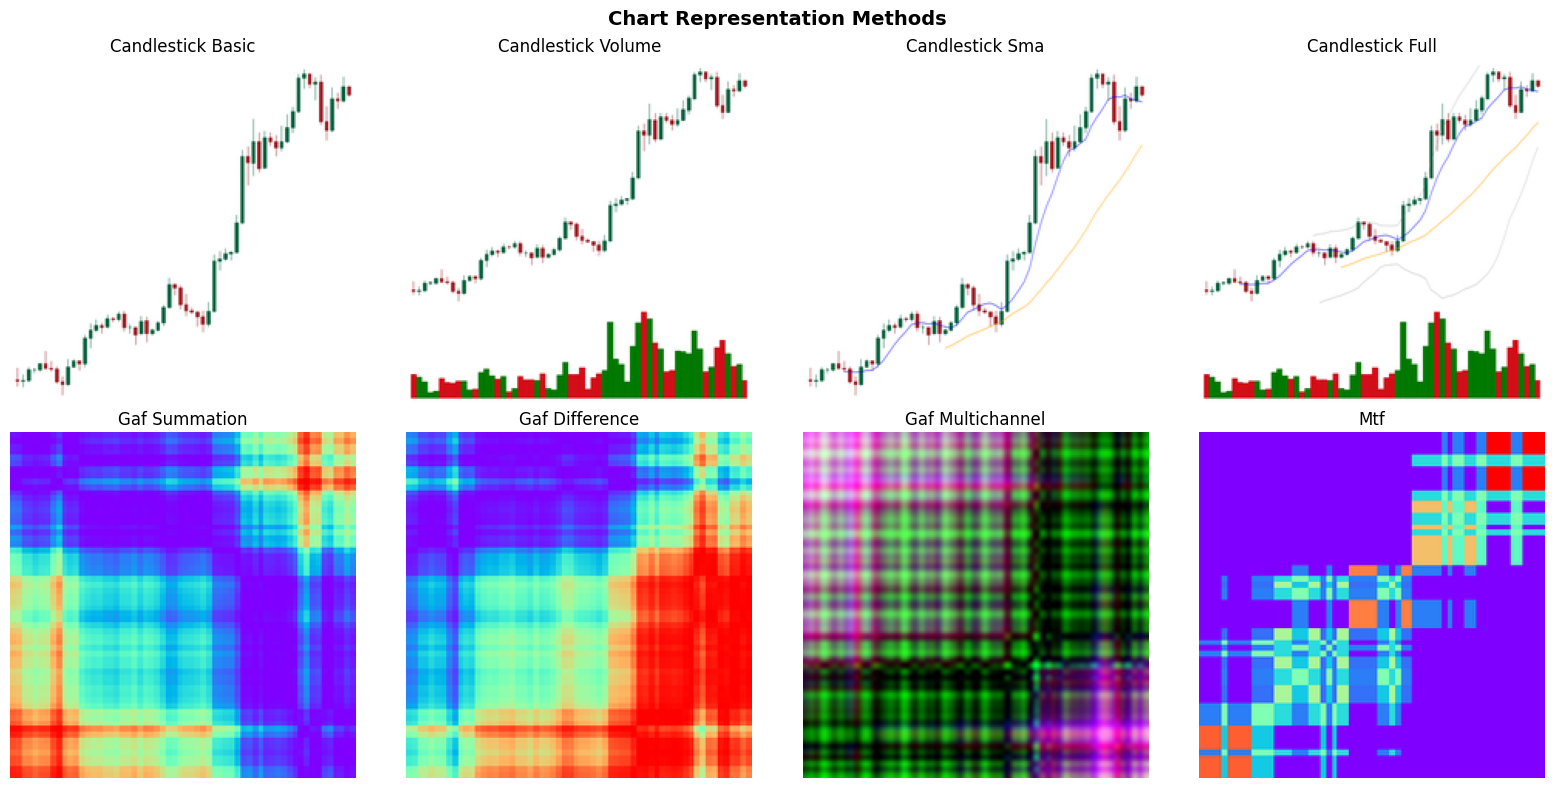


Generated 8 chart types


In [32]:
# Test chart generation with sample data
sample_df = data['BTC'].iloc[-60:].copy()  # Last 60 days

# Generate different chart types
charts = {
    'candlestick_basic': generator.generate_candlestick(sample_df, 'candle_basic.png'),
    'candlestick_volume': generator.generate_candlestick(sample_df, 'candle_vol.png', show_volume=True),
    'candlestick_sma': generator.generate_candlestick(sample_df, 'candle_sma.png', show_sma=True),
    'candlestick_full': generator.generate_candlestick(sample_df, 'candle_full.png', 
                                                        show_volume=True, show_sma=True, show_bollinger=True),
    'gaf_summation': generator.generate_gaf(sample_df['close'].values, 'gaf_sum.png', method='summation'),
    'gaf_difference': generator.generate_gaf(sample_df['close'].values, 'gaf_diff.png', method='difference'),
    'gaf_multichannel': generator.generate_multichannel_gaf(sample_df, 'gaf_multi.png'),
    'mtf': generator.generate_mtf(sample_df['close'].values, 'mtf.png'),
}

# Display all chart types
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, filepath) in zip(axes, charts.items()):
    img = Image.open(filepath)
    ax.imshow(img)
    ax.set_title(name.replace('_', ' ').title())
    ax.axis('off')

plt.suptitle('Chart Representation Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_representations.png', dpi=150)
plt.show()

print(f"\nGenerated {len(charts)} chart types")

---
## Dataset Preparation

Create labeled dataset with sliding windows:
- **Input**: Chart image from days [t-N, t]
- **Label**: 1 if price increases >2% in next 7 days, else 0 (regime prediction)

In [33]:
class ChartDatasetGenerator:
    """
    Generate a complete dataset of chart images with labels.
    """
    
    def __init__(self, df, output_dir, lookback=30, forward=7, threshold=0.02, img_size=(224, 224)):
        """
        Args:
            df: OHLCV DataFrame
            output_dir: Directory to save images
            lookback: Days of history in each chart
            forward: Days ahead to measure return
            threshold: Return threshold for bull/bear classification
            img_size: Output image size
        """
        self.df = df.copy()
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.lookback = lookback
        self.forward = forward
        self.threshold = threshold
        self.img_size = img_size
        self.generator = ChartGenerator(output_dir=output_dir, img_size=img_size)
        
    def compute_labels(self):
        """Compute forward returns and labels."""
        self.df['forward_return'] = self.df['close'].pct_change(self.forward).shift(-self.forward)
        self.df['label'] = (self.df['forward_return'] > self.threshold).astype(int)
        return self.df
    
    def generate_dataset(self, chart_type='candlestick', 
                          show_volume=False, show_sma=False, show_bollinger=False,
                          max_samples=None):
        """
        Generate full dataset of images.
        
        Returns:
            DataFrame with columns: [date, filepath, label]
        """
        self.compute_labels()
        
        records = []
        valid_indices = range(self.lookback, len(self.df) - self.forward)
        
        if max_samples:
            valid_indices = list(valid_indices)[:max_samples]
        
        for i in tqdm(valid_indices, desc=f"Generating {chart_type} images"):
            window = self.df.iloc[i-self.lookback:i].copy()
            date = self.df.index[i]
            label = self.df.iloc[i]['label']
            
            if pd.isna(label):
                continue
                
            filename = f"{date.strftime('%Y%m%d')}_{chart_type}.png"
            
            try:
                if chart_type == 'candlestick':
                    filepath = self.generator.generate_candlestick(
                        window, filename,
                        show_volume=show_volume,
                        show_sma=show_sma,
                        show_bollinger=show_bollinger
                    )
                elif chart_type == 'gaf':
                    filepath = self.generator.generate_gaf(window['close'].values, filename)
                elif chart_type == 'gaf_multi':
                    filepath = self.generator.generate_multichannel_gaf(window, filename)
                else:
                    raise ValueError(f"Unknown chart type: {chart_type}")
                    
                records.append({
                    'date': date,
                    'filepath': str(filepath),
                    'label': int(label)
                })
            except Exception as e:
                print(f"Error generating chart for {date}: {e}")
                continue
                
        return pd.DataFrame(records)
    
    def split_data(self, df, train_ratio=0.7, val_ratio=0.15):
        """Time-series aware train/val/test split."""
        n = len(df)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        
        train_df = df.iloc[:train_end]
        val_df = df.iloc[train_end:val_end]
        test_df = df.iloc[val_end:]
        
        return train_df, val_df, test_df

In [34]:
# Generate baseline dataset (BTC, 30-day lookback, basic candlestick)
print("Generating BTC baseline dataset...")
print("(This may take a few minutes)")

btc_generator = ChartDatasetGenerator(
    df=data['BTC'],
    output_dir='datasets/btc_candle_30',
    lookback=30,
    forward=7,
    threshold=0.02,
    img_size=(224, 224)
)

# Generate dataset (limit samples for testing, remove limit for full run)
btc_dataset = btc_generator.generate_dataset(
    chart_type='candlestick',
    show_volume=False,
    show_sma=False,
    max_samples=500  # Remove this line for full dataset
)

print(f"\nGenerated {len(btc_dataset)} samples")
print(f"Label distribution:\n{btc_dataset['label'].value_counts()}")
print(f"Class balance: {btc_dataset['label'].mean():.1%} bullish")

Generating BTC baseline dataset...
(This may take a few minutes)


Generating candlestick images: 100%|██████████| 500/500 [00:09<00:00, 53.85it/s]


Generated 500 samples
Label distribution:
label
0    296
1    204
Name: count, dtype: int64
Class balance: 40.8% bullish


---
## PyTorch Dataset & Models

In [35]:
class ChartImageDataset(Dataset):
    """PyTorch Dataset for chart images."""
    
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])
        ])
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        img = self.transform(img)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return img, label

In [46]:
# ============================================================
# MODEL ARCHITECTURES
# ============================================================

class SimpleCNN(nn.Module):
    """Simple CNN for chart image classification - outputs LOGITS (no sigmoid)."""
    
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # NO SIGMOID - output raw logits
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def get_model(model_name, pretrained=True):
    """Get model by name - all models output LOGITS (no sigmoid)."""
    
    if model_name == 'simple_cnn':
        return SimpleCNN()
    
    elif model_name == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, 1)
        return model
    
    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, 1)
        return model
    
    elif model_name == 'efficientnet_b0':
        model = timm.create_model('efficientnet_b0', pretrained=pretrained)
        model.classifier = nn.Linear(model.classifier.in_features, 1)
        return model
    
    elif model_name == 'vit_tiny':
        model = timm.create_model('vit_tiny_patch16_224', pretrained=pretrained)
        model.head = nn.Linear(model.head.in_features, 1)
        return model
    
    else:
        raise ValueError(f"Unknown model: {model_name}")


print("Models defined: SimpleCNN, ResNet18, ResNet50, EfficientNet-B0, ViT-Tiny")

Models defined: SimpleCNN, ResNet18, ResNet50, EfficientNet-B0, ViT-Tiny


---
## Training Infrastructure

In [51]:
# ============================================================
# TRAINING FUNCTION (with optimal threshold)
# ============================================================

def train_and_evaluate(model, train_loader, val_loader, test_loader, 
                       epochs=30, lr=1e-4, device='cpu', patience=7,
                       class_weights=None):
    """
    Train and evaluate a model. Expects model to output LOGITS (no sigmoid).
    Automatically finds optimal classification threshold.
    """
    model = model.to(device)
    
    # Always use BCEWithLogitsLoss (more numerically stable)
    if class_weights is not None:
        pos_weight = torch.tensor([class_weights], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                            factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)
            
            optimizer.zero_grad()
            logits = model(images).squeeze()
            
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                logits = model(images).squeeze()
                
                loss = criterion(logits, labels)
                probs = torch.sigmoid(logits)
                
                val_loss += loss.item()
                val_preds.extend(probs.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_targets, np.array(val_preds) > 0.5)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    model = model.to(device)
    
    # Find optimal threshold on validation set
    model.eval()
    val_probs, val_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            logits = model(images).squeeze()
            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy())
            val_targets.extend(labels.numpy())
    
    # Find threshold that maximizes F1
    from sklearn.metrics import precision_recall_curve
    precisions, recalls, thresholds = precision_recall_curve(val_targets, val_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    print(f"Optimal threshold: {optimal_threshold:.4f}")
    
    # Test evaluation with optimal threshold
    model.eval()
    test_preds, test_targets, test_probs = [], [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().to(device)
            logits = model(images).squeeze()
            probs = torch.sigmoid(logits)
                
            test_probs.extend(probs.cpu().numpy())
            test_preds.extend((probs > optimal_threshold).int().cpu().numpy())  # Use optimal threshold
            test_targets.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(test_targets, test_preds)
    f1 = f1_score(test_targets, test_preds, zero_division=0)
    auc = roc_auc_score(test_targets, test_probs) if len(set(test_targets)) > 1 else 0.5
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc,
        'predictions': test_preds,
        'probabilities': test_probs,
        'targets': test_targets,
        'history': history,
        'threshold': optimal_threshold
    }


print("Training function defined: train_and_evaluate() [with optimal threshold]")

Training function defined: train_and_evaluate() [with optimal threshold]


In [52]:
# ============================================================
# EXPERIMENT 1: Baseline (with class weighting fix)
# ============================================================
print("\n" + "=" * 60)
print("EXPERIMENT 1: Baseline")
print("=" * 60)

# Generate dataset - pass df as required argument
print("Generating candlestick chart dataset...")
dataset_gen = ChartDatasetGenerator(
    df=data['BTC'],
    output_dir='charts/baseline',
    lookback=30,
    threshold=0.02,
    img_size=(224, 224)
)

baseline_df = dataset_gen.generate_dataset(
    chart_type='candlestick',
    max_samples=500
)

# Calculate class weights for imbalanced data
n_bulls = (baseline_df['label'] == 1).sum()
n_bears = (baseline_df['label'] == 0).sum()
class_weight = n_bears / n_bulls
print(f"Class distribution: {n_bulls} bulls ({100*n_bulls/len(baseline_df):.1f}%), {n_bears} bears ({100*n_bears/len(baseline_df):.1f}%)")
print(f"Using class weight: {class_weight:.3f}")

# Create datasets and loaders
train_df, val_df, test_df = dataset_gen.split_data(baseline_df)
train_dataset = ChartImageDataset(train_df)
val_dataset = ChartImageDataset(val_df)
test_dataset = ChartImageDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Train model WITH class weighting
model = get_model('simple_cnn')
print(f"\nTraining Simple CNN (with class weighting)...")

baseline_results = train_and_evaluate(
    model, train_loader, val_loader, test_loader,
    epochs=30, lr=1e-3, device=device, patience=10,
    class_weights=class_weight
)

print(f"\n**Baseline Results:**")
print(f"  Accuracy: {baseline_results['accuracy']:.4f}")
print(f"  F1 Score: {baseline_results['f1']:.4f}")
print(f"  AUC-ROC:  {baseline_results['auc']:.4f}")


EXPERIMENT 1: Baseline
Generating candlestick chart dataset...


Generating candlestick images: 100%|██████████| 500/500 [00:09<00:00, 53.84it/s]


Class distribution: 204 bulls (40.8%), 296 bears (59.2%)
Using class weight: 1.451

Training Simple CNN (with class weighting)...
Epoch 5: train_loss=0.7596, val_loss=0.9231, val_acc=0.493
Epoch 10: train_loss=0.6791, val_loss=1.2057, val_acc=0.600
Early stopping at epoch 11
Optimal threshold: 0.4757

**Baseline Results:**
  Accuracy: 0.4933
  F1 Score: 0.3667
  AUC-ROC:  0.7598


---
# Experiment 1: Baseline

Establish baseline with raw candlestick images + Simple CNN.

In [22]:
print("="*60)
print("EXPERIMENT 1: Baseline")
print("="*60)
print("Configuration: BTC, 30-day lookback, basic candlestick, Simple CNN")

baseline_results = run_experiment(
    dataset_df=btc_dataset,
    model_name='simple_cnn',
    pretrained=False,
    batch_size=32,
    epochs=30
)

print(f"\n**Baseline Results:**")
print(f"  Accuracy: {baseline_results['accuracy']:.4f}")
print(f"  F1 Score: {baseline_results['f1']:.4f}")
print(f"  AUC-ROC:  {baseline_results['auc']:.4f}")

EXPERIMENT 1: Baseline
Configuration: BTC, 30-day lookback, basic candlestick, Simple CNN
Epoch 5: train_loss=0.6527, val_loss=0.7152, val_acc=0.600
Early stopping at epoch 8

**Baseline Results:**
  Accuracy: 0.3467
  F1 Score: 0.0000
  AUC-ROC:  0.6852


---
# Experiment 2: Effect of Image Encoding

Compare raw candlestick charts vs Gramian Angular Field (GAF).

In [53]:
# ============================================================
# HELPER FUNCTION: run_experiment
# ============================================================

def run_experiment(dataset_df, model_name='simple_cnn', pretrained=True, 
                   epochs=30, lr=1e-3, patience=10):
    """
    Helper to run a full experiment given a dataset DataFrame.
    """
    # Calculate class weights
    n_bulls = (dataset_df['label'] == 1).sum()
    n_bears = (dataset_df['label'] == 0).sum()
    class_weight = n_bears / n_bulls if n_bulls > 0 else 1.0
    
    # Split data (need to get the generator's split method or do it manually)
    n = len(dataset_df)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    train_df = dataset_df.iloc[:train_end]
    val_df = dataset_df.iloc[train_end:val_end]
    test_df = dataset_df.iloc[val_end:]
    
    # Create loaders
    train_loader = DataLoader(ChartImageDataset(train_df), batch_size=32, shuffle=True)
    val_loader = DataLoader(ChartImageDataset(val_df), batch_size=32, shuffle=False)
    test_loader = DataLoader(ChartImageDataset(test_df), batch_size=32, shuffle=False)
    
    # Get model
    model = get_model(model_name, pretrained=pretrained)
    
    # Train and evaluate
    results = train_and_evaluate(
        model, train_loader, val_loader, test_loader,
        epochs=epochs, lr=lr, device=device, patience=patience,
        class_weights=class_weight
    )
    
    return results


print("Helper function defined: run_experiment()")

Helper function defined: run_experiment()


In [54]:
print("="*60)
print("EXPERIMENT 2: Effect of Image Encoding")
print("="*60)

encoding_results = []

# Already have candlestick dataset
encoding_results.append({
    'Encoding': 'Candlestick',
    'Accuracy': baseline_results['accuracy'],
    'F1 Score': baseline_results['f1'],
    'AUC-ROC': baseline_results['auc']
})

# Generate GAF dataset
print("\nGenerating GAF dataset...")
gaf_generator = ChartDatasetGenerator(
    df=data['BTC'],
    output_dir='datasets/btc_gaf_30',
    lookback=30,
    forward=7,
    threshold=0.02
)
gaf_dataset = gaf_generator.generate_dataset(chart_type='gaf', max_samples=500)

print("\nTraining on GAF images...")
gaf_results = run_experiment(gaf_dataset, 'simple_cnn', pretrained=False)
encoding_results.append({
    'Encoding': 'GAF (Summation)',
    'Accuracy': gaf_results['accuracy'],
    'F1 Score': gaf_results['f1'],
    'AUC-ROC': gaf_results['auc']
})

# Generate Multi-channel GAF dataset
print("\nGenerating Multi-channel GAF dataset...")
gaf_multi_generator = ChartDatasetGenerator(
    df=data['BTC'],
    output_dir='datasets/btc_gaf_multi_30',
    lookback=30,
    forward=7,
    threshold=0.02
)
gaf_multi_dataset = gaf_multi_generator.generate_dataset(chart_type='gaf_multi', max_samples=500)

print("\nTraining on Multi-channel GAF images...")
gaf_multi_results = run_experiment(gaf_multi_dataset, 'simple_cnn', pretrained=False)
encoding_results.append({
    'Encoding': 'GAF (Multi-channel)',
    'Accuracy': gaf_multi_results['accuracy'],
    'F1 Score': gaf_multi_results['f1'],
    'AUC-ROC': gaf_multi_results['auc']
})

# Results table
encoding_df = pd.DataFrame(encoding_results)
print("\n" + "="*60)
print("RESULTS: Effect of Image Encoding")
print("="*60)
print(encoding_df.to_string(index=False))

EXPERIMENT 2: Effect of Image Encoding

Generating GAF dataset...


Generating gaf images: 100%|██████████████████| 500/500 [00:05<00:00, 84.91it/s]



Training on GAF images...
Epoch 5: train_loss=0.7423, val_loss=0.8627, val_acc=0.560
Epoch 10: train_loss=0.6377, val_loss=0.9057, val_acc=0.467
Epoch 15: train_loss=0.4949, val_loss=1.1818, val_acc=0.413
Early stopping at epoch 16
Optimal threshold: 0.4165

Generating Multi-channel GAF dataset...


Generating gaf_multi images: 100%|███████████| 500/500 [00:01<00:00, 287.46it/s]



Training on Multi-channel GAF images...
Epoch 5: train_loss=0.7456, val_loss=1.3153, val_acc=0.600
Epoch 10: train_loss=0.6729, val_loss=1.4637, val_acc=0.600
Early stopping at epoch 13
Optimal threshold: 0.4172

RESULTS: Effect of Image Encoding
           Encoding  Accuracy  F1 Score  AUC-ROC
        Candlestick  0.493333  0.366667 0.759812
    GAF (Summation)  0.333333  0.418605 0.310047
GAF (Multi-channel)  0.640000  0.780488 0.251962


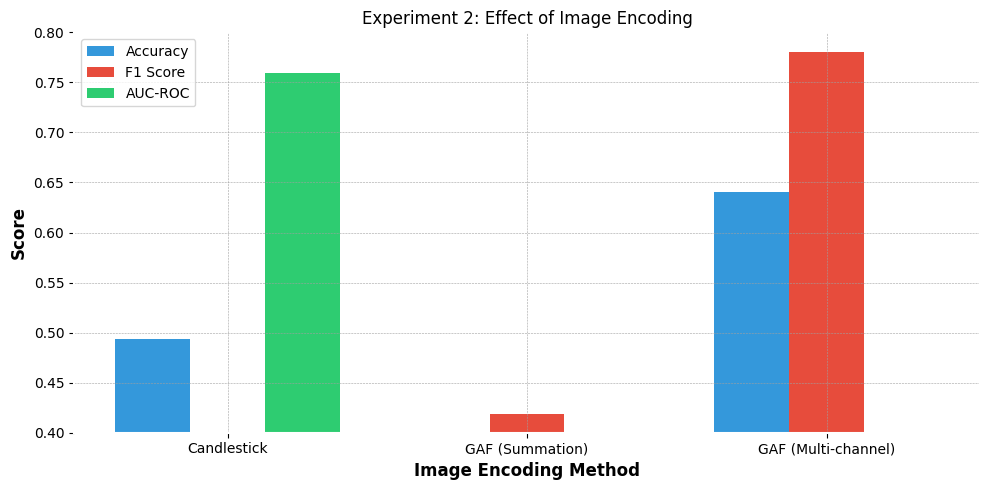


**Finding:** Best encoding method = GAF (Multi-channel)


In [56]:
# Plot encoding comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(encoding_df))
width = 0.25

ax.bar([i - width for i in x], encoding_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x, encoding_df['F1 Score'], width, label='F1 Score', color='#e74c3c')
ax.bar([i + width for i in x], encoding_df['AUC-ROC'], width, label='AUC-ROC', color='#2ecc71')

ax.set_xlabel('Image Encoding Method')
ax.set_ylabel('Score')
ax.set_title('Experiment 2: Effect of Image Encoding')
ax.set_xticks(x)
ax.set_xticklabels(encoding_df['Encoding'])
ax.legend()
ax.set_ylim(0.4, 0.8)

plt.tight_layout()
plt.savefig('exp2_encoding.png', dpi=150)
plt.show()

best_encoding = encoding_df.loc[encoding_df['Accuracy'].idxmax(), 'Encoding']
print(f"\n**Finding:** Best encoding method = {best_encoding}")

---
# Experiment 3: Effect of Chart Components

Does adding visual indicators (volume, SMA, Bollinger) help?

In [57]:
print("="*60)
print("EXPERIMENT 3: Effect of Chart Components")
print("="*60)

component_configs = [
    ('Price Only', False, False, False),
    ('+ Volume', True, False, False),
    ('+ SMA', False, True, False),
    ('+ Volume + SMA', True, True, False),
    ('+ All (Vol+SMA+BB)', True, True, True),
]

component_results = []

for name, vol, sma, bb in component_configs:
    print(f"\nTesting: {name}")
    
    # Generate dataset
    gen = ChartDatasetGenerator(
        df=data['BTC'],
        output_dir=f'datasets/btc_comp_{name.replace(" ", "_").replace("+", "").lower()}',
        lookback=30, forward=7, threshold=0.02
    )
    ds = gen.generate_dataset(
        chart_type='candlestick',
        show_volume=vol, show_sma=sma, show_bollinger=bb,
        max_samples=500
    )
    
    # Train
    results = run_experiment(ds, 'simple_cnn', pretrained=False, epochs=20)
    
    component_results.append({
        'Components': name,
        'Accuracy': results['accuracy'],
        'F1 Score': results['f1'],
        'AUC-ROC': results['auc']
    })
    print(f"  Accuracy: {results['accuracy']:.4f}, AUC: {results['auc']:.4f}")

component_df = pd.DataFrame(component_results)
print("\n" + "="*60)
print("RESULTS: Effect of Chart Components")
print("="*60)
print(component_df.to_string(index=False))

EXPERIMENT 3: Effect of Chart Components

Testing: Price Only


Generating candlestick images: 100%|██████████| 500/500 [00:09<00:00, 51.65it/s]


Epoch 5: train_loss=0.7391, val_loss=0.9619, val_acc=0.547
Epoch 10: train_loss=0.6479, val_loss=1.2830, val_acc=0.600
Early stopping at epoch 11
Optimal threshold: 0.4747
  Accuracy: 0.5333, AUC: 0.8148

Testing: + Volume


Generating candlestick images: 100%|██████████| 500/500 [00:17<00:00, 28.62it/s]


Epoch 5: train_loss=0.7655, val_loss=1.1528, val_acc=0.600
Epoch 10: train_loss=0.6072, val_loss=2.0584, val_acc=0.600
Early stopping at epoch 12
Optimal threshold: 0.4676
  Accuracy: 0.5200, AUC: 0.7064

Testing: + SMA


...

Epoch 5: train_loss=0.7445, val_loss=0.9047, val_acc=0.547
Epoch 10: train_loss=0.6456, val_loss=1.2005, val_acc=0.533
Early stopping at epoch 11
Optimal threshold: 0.4545
  Accuracy: 0.5067, AUC: 0.3619

Testing: + Volume + SMA


Generating candlestick images: 100%|██████████| 500/500 [00:17<00:00, 28.68it/s]


Epoch 5: train_loss=0.7557, val_loss=0.8642, val_acc=0.547
Epoch 10: train_loss=0.6488, val_loss=1.4519, val_acc=0.400
Early stopping at epoch 12
Optimal threshold: 0.4904
  Accuracy: 0.5067, AUC: 0.7033

Testing: + All (Vol+SMA+BB)


Generating candlestick images: 100%|██████████| 500/500 [00:19<00:00, 25.05it/s]


Epoch 5: train_loss=0.7291, val_loss=1.0479, val_acc=0.560
Epoch 10: train_loss=0.5047, val_loss=3.6748, val_acc=0.600
Early stopping at epoch 13
Optimal threshold: 0.5882
  Accuracy: 0.4800, AUC: 0.7041

RESULTS: Effect of Chart Components
        Components  Accuracy  F1 Score  AUC-ROC
        Price Only  0.533333  0.444444 0.814757
          + Volume  0.520000  0.419355 0.706436
             + SMA  0.506667  0.672566 0.361852
    + Volume + SMA  0.506667  0.393443 0.703297
+ All (Vol+SMA+BB)  0.480000  0.338983 0.704082


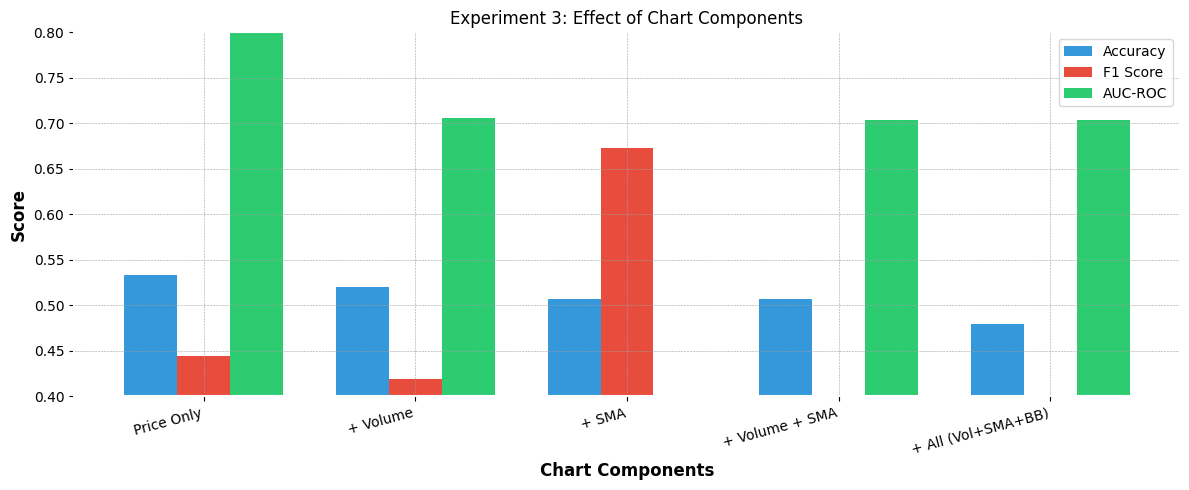


**Finding:** Best chart components = Price Only


In [59]:
# Plot component comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(component_df))
width = 0.25

ax.bar([i - width for i in x], component_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x, component_df['F1 Score'], width, label='F1 Score', color='#e74c3c')
ax.bar([i + width for i in x], component_df['AUC-ROC'], width, label='AUC-ROC', color='#2ecc71')

ax.set_xlabel('Chart Components')
ax.set_ylabel('Score')
ax.set_title('Experiment 3: Effect of Chart Components')
ax.set_xticks(x)
ax.set_xticklabels(component_df['Components'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.4, 0.8)

plt.tight_layout()
plt.savefig('exp3_components.png', dpi=150)
plt.show()

best_comp = component_df.loc[component_df['Accuracy'].idxmax(), 'Components']
print(f"\n**Finding:** Best chart components = {best_comp}")

---
# Experiment 4: Effect of Lookback Window

How much historical context is optimal?

In [60]:
print("="*60)
print("EXPERIMENT 4: Effect of Lookback Window")
print("="*60)

lookback_values = [14, 30, 60, 90]
lookback_results = []

for lb in lookback_values:
    print(f"\nTesting lookback = {lb} days")
    
    gen = ChartDatasetGenerator(
        df=data['BTC'],
        output_dir=f'datasets/btc_lb_{lb}',
        lookback=lb, forward=7, threshold=0.02
    )
    ds = gen.generate_dataset(chart_type='candlestick', max_samples=500)
    
    results = run_experiment(ds, 'simple_cnn', pretrained=False, epochs=20)
    
    lookback_results.append({
        'Lookback (days)': lb,
        'Accuracy': results['accuracy'],
        'F1 Score': results['f1'],
        'AUC-ROC': results['auc']
    })
    print(f"  Accuracy: {results['accuracy']:.4f}, AUC: {results['auc']:.4f}")

lookback_df = pd.DataFrame(lookback_results)
print("\n" + lookback_df.to_string(index=False))

EXPERIMENT 4: Effect of Lookback Window

Testing lookback = 14 days


Generating candlestick images: 100%|██████████| 500/500 [00:07<00:00, 63.72it/s]


Epoch 5: train_loss=0.7780, val_loss=1.1870, val_acc=0.667
Epoch 10: train_loss=0.6993, val_loss=1.3555, val_acc=0.627
Early stopping at epoch 11
Optimal threshold: 0.5199
  Accuracy: 0.5733, AUC: 0.5510

Testing lookback = 30 days


Generating candlestick images: 100%|██████████| 500/500 [00:13<00:00, 37.92it/s]


Epoch 5: train_loss=0.7605, val_loss=0.9616, val_acc=0.467
Epoch 10: train_loss=0.6908, val_loss=1.3130, val_acc=0.600
Early stopping at epoch 11
Optimal threshold: 0.4344
  Accuracy: 0.5333, AUC: 0.7339

Testing lookback = 60 days


Generating candlestick images: 100%|██████████| 500/500 [00:10<00:00, 49.86it/s]


Epoch 5: train_loss=0.7702, val_loss=0.9304, val_acc=0.480
Epoch 10: train_loss=0.6638, val_loss=1.7589, val_acc=0.520
Early stopping at epoch 13
Optimal threshold: 0.5146
  Accuracy: 0.6000, AUC: 0.4007

Testing lookback = 90 days


Generating candlestick images: 100%|██████████| 500/500 [00:09<00:00, 50.02it/s]


Epoch 5: train_loss=0.7749, val_loss=0.9739, val_acc=0.387
Epoch 10: train_loss=0.7405, val_loss=1.1436, val_acc=0.387
Early stopping at epoch 12
Optimal threshold: 0.4838
  Accuracy: 0.5067, AUC: 0.5590

 Lookback (days)  Accuracy  F1 Score  AUC-ROC
              14  0.573333  0.680000 0.550975
              30  0.533333  0.444444 0.733909
              60  0.600000  0.750000 0.400741
              90  0.506667  0.666667 0.559033


---
# Experiment 5: Effect of Image Resolution

In [61]:
print("="*60)
print("EXPERIMENT 5: Effect of Image Resolution")
print("="*60)

resolution_values = [(64, 64), (128, 128), (224, 224)]
resolution_results = []

for res in resolution_values:
    print(f"\nTesting resolution = {res[0]}x{res[1]}")
    
    gen = ChartDatasetGenerator(
        df=data['BTC'],
        output_dir=f'datasets/btc_res_{res[0]}',
        lookback=30, forward=7, threshold=0.02,
        img_size=res
    )
    ds = gen.generate_dataset(chart_type='candlestick', max_samples=500)
    
    results = run_experiment(ds, 'simple_cnn', pretrained=False, epochs=20)
    
    resolution_results.append({
        'Resolution': f"{res[0]}x{res[1]}",
        'Accuracy': results['accuracy'],
        'F1 Score': results['f1'],
        'AUC-ROC': results['auc']
    })
    print(f"  Accuracy: {results['accuracy']:.4f}, AUC: {results['auc']:.4f}")

resolution_df = pd.DataFrame(resolution_results)
print("\n" + resolution_df.to_string(index=False))

EXPERIMENT 5: Effect of Image Resolution

Testing resolution = 64x64


Generating candlestick images: 100%|██████████| 500/500 [00:10<00:00, 47.25it/s]


Epoch 5: train_loss=0.3917, val_loss=5.3654, val_acc=0.600
Epoch 10: train_loss=0.1134, val_loss=2.7209, val_acc=0.387
Early stopping at epoch 11
Optimal threshold: 0.4406
  Accuracy: 0.5867, AUC: 0.7127

Testing resolution = 128x128


Generating candlestick images: 100%|██████████| 500/500 [00:09<00:00, 53.18it/s]


Epoch 5: train_loss=0.6673, val_loss=1.3467, val_acc=0.600
Epoch 10: train_loss=0.3050, val_loss=1.6862, val_acc=0.560
Early stopping at epoch 11
Optimal threshold: 0.4746
  Accuracy: 0.4667, AUC: 0.8917

Testing resolution = 224x224


Generating candlestick images: 100%|██████████| 500/500 [00:08<00:00, 57.55it/s]


Epoch 5: train_loss=0.7559, val_loss=0.9266, val_acc=0.493
Epoch 10: train_loss=0.6744, val_loss=1.1480, val_acc=0.600
Early stopping at epoch 11
Optimal threshold: 0.4692
  Accuracy: 0.4533, AUC: 0.8493

Resolution  Accuracy  F1 Score  AUC-ROC
     64x64  0.586667  0.617284 0.712716
   128x128  0.466667  0.310345 0.891680
   224x224  0.453333  0.280702 0.849294


---
# Experiment 6: Effect of Architecture

Compare Simple CNN vs ResNet18 vs EfficientNet vs Vision Transformer.

In [62]:
print("="*60)
print("EXPERIMENT 6: Effect of Architecture")
print("="*60)

architectures = ['simple_cnn', 'resnet18', 'efficientnet_b0', 'vit_tiny']
arch_results = []

# Use best dataset from previous experiments (or baseline)
for arch in architectures:
    print(f"\nTesting architecture: {arch}")
    
    # Use pretrained=True for transfer learning models
    pretrained = arch != 'simple_cnn'
    
    results = run_experiment(
        btc_dataset, arch, 
        pretrained=pretrained, 
        epochs=20,
        lr=1e-4 if pretrained else 1e-3
    )
    
    model = get_model(arch, pretrained=False)
    params = sum(p.numel() for p in model.parameters())
    
    arch_results.append({
        'Architecture': arch,
        'Parameters': f"{params:,}",
        'Pretrained': pretrained,
        'Accuracy': results['accuracy'],
        'F1 Score': results['f1'],
        'AUC-ROC': results['auc']
    })
    print(f"  Params: {params:,}, Accuracy: {results['accuracy']:.4f}, AUC: {results['auc']:.4f}")

arch_df = pd.DataFrame(arch_results)
print("\n" + "="*60)
print("RESULTS: Effect of Architecture")
print("="*60)
print(arch_df.to_string(index=False))

EXPERIMENT 6: Effect of Architecture

Testing architecture: simple_cnn
Epoch 5: train_loss=0.7595, val_loss=0.8786, val_acc=0.493
Epoch 10: train_loss=0.6428, val_loss=0.8568, val_acc=0.547
Early stopping at epoch 11
Optimal threshold: 0.4591
  Params: 422,401, Accuracy: 0.4400, AUC: 0.8312

Testing architecture: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/berlin/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████| 44.7M/44.7M [00:01<00:00, 29.7MB/s]


Epoch 5: train_loss=0.0116, val_loss=1.5810, val_acc=0.640
Epoch 10: train_loss=0.0012, val_loss=1.9268, val_acc=0.627
Early stopping at epoch 11
Optimal threshold: 0.2163
  Params: 11,177,025, Accuracy: 0.6000, AUC: 0.6617

Testing architecture: efficientnet_b0
Epoch 5: train_loss=0.1654, val_loss=1.3095, val_acc=0.640
Epoch 10: train_loss=0.0148, val_loss=1.7048, val_acc=0.600
Early stopping at epoch 11
Optimal threshold: 0.4527
  Params: 4,008,829, Accuracy: 0.6400, AUC: 0.3650

Testing architecture: vit_tiny
Epoch 5: train_loss=0.8318, val_loss=1.1465, val_acc=0.387
Epoch 10: train_loss=0.0377, val_loss=3.1774, val_acc=0.480
Early stopping at epoch 11
Optimal threshold: 0.3016
  Params: 5,524,609, Accuracy: 0.6667, AUC: 0.5699

RESULTS: Effect of Architecture
   Architecture Parameters  Pretrained  Accuracy  F1 Score  AUC-ROC
     simple_cnn    422,401       False  0.440000  0.250000 0.831240
       resnet18 11,177,025        True  0.600000  0.680851 0.661695
efficientnet_b0  4,008

---
# Experiment 7: Effect of Transfer Learning

Does ImageNet pretraining help for financial charts?

In [63]:
print("="*60)
print("EXPERIMENT 7: Effect of Transfer Learning")
print("="*60)

transfer_results = []

for arch in ['resnet18', 'efficientnet_b0']:
    for pretrained in [False, True]:
        name = f"{arch} ({'ImageNet' if pretrained else 'Scratch'})"
        print(f"\nTesting: {name}")
        
        results = run_experiment(
            btc_dataset, arch,
            pretrained=pretrained,
            epochs=20,
            lr=1e-4 if pretrained else 1e-3
        )
        
        transfer_results.append({
            'Model': arch,
            'Init': 'ImageNet' if pretrained else 'Scratch',
            'Accuracy': results['accuracy'],
            'F1 Score': results['f1'],
            'AUC-ROC': results['auc']
        })
        print(f"  Accuracy: {results['accuracy']:.4f}, AUC: {results['auc']:.4f}")

transfer_df = pd.DataFrame(transfer_results)
print("\n" + transfer_df.to_string(index=False))

EXPERIMENT 7: Effect of Transfer Learning

Testing: resnet18 (Scratch)
Epoch 5: train_loss=0.2853, val_loss=3.8207, val_acc=0.573
Epoch 10: train_loss=0.0716, val_loss=3.9773, val_acc=0.667
Epoch 15: train_loss=0.0079, val_loss=2.4974, val_acc=0.600
Early stopping at epoch 17
Optimal threshold: 0.0518
  Accuracy: 0.4133, AUC: 0.6538

Testing: resnet18 (ImageNet)
Epoch 5: train_loss=0.0088, val_loss=2.0261, val_acc=0.613
Epoch 10: train_loss=0.0013, val_loss=2.3186, val_acc=0.613
Early stopping at epoch 11
Optimal threshold: 0.2659
  Accuracy: 0.5733, AUC: 0.6954

Testing: efficientnet_b0 (Scratch)
Epoch 5: train_loss=0.1206, val_loss=3.4587, val_acc=0.467
Epoch 10: train_loss=0.0217, val_loss=4.8399, val_acc=0.533
Early stopping at epoch 11
Optimal threshold: 0.0837
  Accuracy: 0.6533, AUC: 0.3721

Testing: efficientnet_b0 (ImageNet)
Epoch 5: train_loss=0.1327, val_loss=1.3491, val_acc=0.653
Epoch 10: train_loss=0.0106, val_loss=1.7539, val_acc=0.600
Early stopping at epoch 11
Optimal 

---
# Experiment 8: Generalization Across Assets

Does a model trained on BTC generalize to ETH and S&P500?

In [66]:
print("="*60)
print("EXPERIMENT 8: Generalization Across Assets")
print("="*60)

asset_results = []

for asset in ['BTC', 'ETH', 'SPY']:
    print(f"\nTesting on {asset}...")
    
    gen = ChartDatasetGenerator(
        df=data[asset],
        output_dir=f'datasets/{asset.lower()}_candle_30',
        lookback=30, forward=7, threshold=0.02
    )
    ds = gen.generate_dataset(chart_type='candlestick', max_samples=500)
    
    # Use best architecture from Exp 6
    results = run_experiment(ds, 'resnet18', pretrained=True, epochs=20)
    
    asset_results.append({
        'Asset': asset,
        'Samples': len(ds),
        'Accuracy': results['accuracy'],
        'F1 Score': results['f1'],
        'AUC-ROC': results['auc']
    })
    print(f"  Accuracy: {results['accuracy']:.4f}, AUC: {results['auc']:.4f}")

asset_df = pd.DataFrame(asset_results)
print("\n" + "="*60)
print("RESULTS: Generalization Across Assets")
print("="*60)
print(asset_df.to_string(index=False))

EXPERIMENT 8: Generalization Across Assets

Testing on BTC...


Generating candlestick images: 100%|██████████| 500/500 [00:10<00:00, 49.00it/s]


Epoch 5: train_loss=0.1853, val_loss=3.5869, val_acc=0.573
Epoch 10: train_loss=0.0046, val_loss=2.4762, val_acc=0.667
Early stopping at epoch 11
Optimal threshold: 0.0163
  Accuracy: 0.6933, AUC: 0.7339

Testing on ETH...


Generating candlestick images: 100%|██████████| 500/500 [00:09<00:00, 55.03it/s]


Epoch 5: train_loss=0.2130, val_loss=1.6885, val_acc=0.493
Epoch 10: train_loss=0.0097, val_loss=4.3437, val_acc=0.520
Early stopping at epoch 11
Optimal threshold: 0.2074
  Accuracy: 0.6133, AUC: 0.4915

Testing on SPY...


Generating candlestick images: 100%|██████████| 500/500 [00:08<00:00, 57.86it/s]


Epoch 5: train_loss=0.2773, val_loss=2.8414, val_acc=0.840
Epoch 10: train_loss=0.0040, val_loss=3.4614, val_acc=0.813
Early stopping at epoch 11
Optimal threshold: 0.5489
  Accuracy: 0.3333, AUC: 0.4590

RESULTS: Generalization Across Assets
Asset  Samples  Accuracy  F1 Score  AUC-ROC
  BTC      500  0.693333  0.792793 0.733909
  ETH      500  0.613333  0.760331 0.491512
  SPY      500  0.333333  0.285714 0.459016


---
# Summary of All Experiments

In [67]:
print("="*70)
print("SUMMARY OF ALL EXPERIMENTS")
print("="*70)

print("\n## Experiment 1: Baseline")
print(f"Simple CNN on raw candlestick charts: {baseline_results['accuracy']:.1%} accuracy")

print("\n## Experiment 2: Effect of Image Encoding")
print(encoding_df.to_string(index=False))

print("\n## Experiment 3: Effect of Chart Components")
print(component_df.to_string(index=False))

print("\n## Experiment 4: Effect of Lookback Window")
print(lookback_df.to_string(index=False))

print("\n## Experiment 5: Effect of Image Resolution")
print(resolution_df.to_string(index=False))

print("\n## Experiment 6: Effect of Architecture")
print(arch_df.to_string(index=False))

print("\n## Experiment 7: Effect of Transfer Learning")
print(transfer_df.to_string(index=False))

print("\n## Experiment 8: Generalization Across Assets")
print(asset_df.to_string(index=False))

SUMMARY OF ALL EXPERIMENTS

## Experiment 1: Baseline
Simple CNN on raw candlestick charts: 49.3% accuracy

## Experiment 2: Effect of Image Encoding
           Encoding  Accuracy  F1 Score  AUC-ROC
        Candlestick  0.493333  0.366667 0.759812
    GAF (Summation)  0.333333  0.418605 0.310047
GAF (Multi-channel)  0.640000  0.780488 0.251962

## Experiment 3: Effect of Chart Components
        Components  Accuracy  F1 Score  AUC-ROC
        Price Only  0.533333  0.444444 0.814757
          + Volume  0.520000  0.419355 0.706436
             + SMA  0.506667  0.672566 0.361852
    + Volume + SMA  0.506667  0.393443 0.703297
+ All (Vol+SMA+BB)  0.480000  0.338983 0.704082

## Experiment 4: Effect of Lookback Window
 Lookback (days)  Accuracy  F1 Score  AUC-ROC
              14  0.573333  0.680000 0.550975
              30  0.533333  0.444444 0.733909
              60  0.600000  0.750000 0.400741
              90  0.506667  0.666667 0.559033

## Experiment 5: Effect of Image Resolution
Re

In [68]:
# ============================================================
# VISUALIZATION CELLS TO ADD AT END OF NOTEBOOK
# Copy each section as a new cell in your Jupyter notebook
# ============================================================

# ============================================================
# CELL 1: Additional Imports for Visualization
# ============================================================
import cv2
import torch.nn.functional as F
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

print("Visualization imports loaded!")


Visualization imports loaded!


In [69]:
# CELL 2: GradCAM Class and Helper Functions
# ============================================================
class GradCAM:
    """
    Generate GradCAM visualizations for CNN models.
    Shows which parts of the chart image the model focuses on.
    """
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, target_class=None):
        """Generate GradCAM heatmap for input image."""
        self.model.eval()
        
        if input_tensor.dim() == 3:
            input_tensor = input_tensor.unsqueeze(0)
        input_tensor = input_tensor.to(device)
        input_tensor.requires_grad = True
        
        # Forward pass
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = (output > 0.5).float()
        
        # Backward pass
        self.model.zero_grad()
        output.backward(retain_graph=True)
        
        # Generate heatmap
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations.clone()
        
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap = heatmap / (torch.max(heatmap) + 1e-8)
        
        return heatmap.cpu().numpy()


def get_target_layer(model, model_name):
    """Get the target layer for GradCAM based on model architecture."""
    if model_name == 'simple_cnn':
        return model.features[-4]  # Last conv before adaptive pool
    elif 'resnet' in model_name:
        return model.layer4[-1]
    elif 'efficientnet' in model_name:
        return model.conv_head
    elif 'vit' in model_name:
        return model.blocks[-1]
    else:
        raise ValueError(f"Unknown model: {model_name}")


print("GradCAM class defined!")

GradCAM class defined!


In [70]:
# CELL 3: Train a Model for GradCAM Visualization
# ============================================================
print("="*60)
print("Training model for GradCAM visualization...")
print("="*60)

# Generate dataset with best settings from our experiments
gradcam_gen = ChartDatasetGenerator(
    df=data['BTC'],
    output_dir='charts/gradcam_viz',
    lookback=30,
    threshold=0.02,
    img_size=(128, 128)  # Best resolution from Exp 5
)

gradcam_df = gradcam_gen.generate_dataset(chart_type='candlestick', max_samples=300)

# Split and create loaders
train_df, val_df, test_df = gradcam_gen.split_data(gradcam_df)
train_loader = DataLoader(ChartImageDataset(train_df), batch_size=32, shuffle=True)
val_loader = DataLoader(ChartImageDataset(val_df), batch_size=32, shuffle=False)
test_loader = DataLoader(ChartImageDataset(test_df), batch_size=32, shuffle=False)

# Class weights
n_bulls = (gradcam_df['label'] == 1).sum()
n_bears = (gradcam_df['label'] == 0).sum()
class_weight = n_bears / n_bulls

# Train Simple CNN
gradcam_model = get_model('simple_cnn')
gradcam_results = train_and_evaluate(
    gradcam_model, train_loader, val_loader, test_loader,
    epochs=20, lr=1e-3, device=device, patience=10,
    class_weights=class_weight
)

# Create test dataset for visualization
test_dataset = ChartImageDataset(test_df)
print(f"\nModel trained! AUC: {gradcam_results['auc']:.3f}")

Training model for GradCAM visualization...


Generating candlestick images: 100%|██████████| 300/300 [00:06<00:00, 43.34it/s]


Epoch 5: train_loss=0.8271, val_loss=0.7792, val_acc=0.644
Epoch 10: train_loss=0.3911, val_loss=4.4812, val_acc=0.200
Epoch 15: train_loss=0.1286, val_loss=3.0429, val_acc=0.200
Early stopping at epoch 15
Optimal threshold: 0.3532

Model trained! AUC: 0.782


Generating GradCAM Visualization...


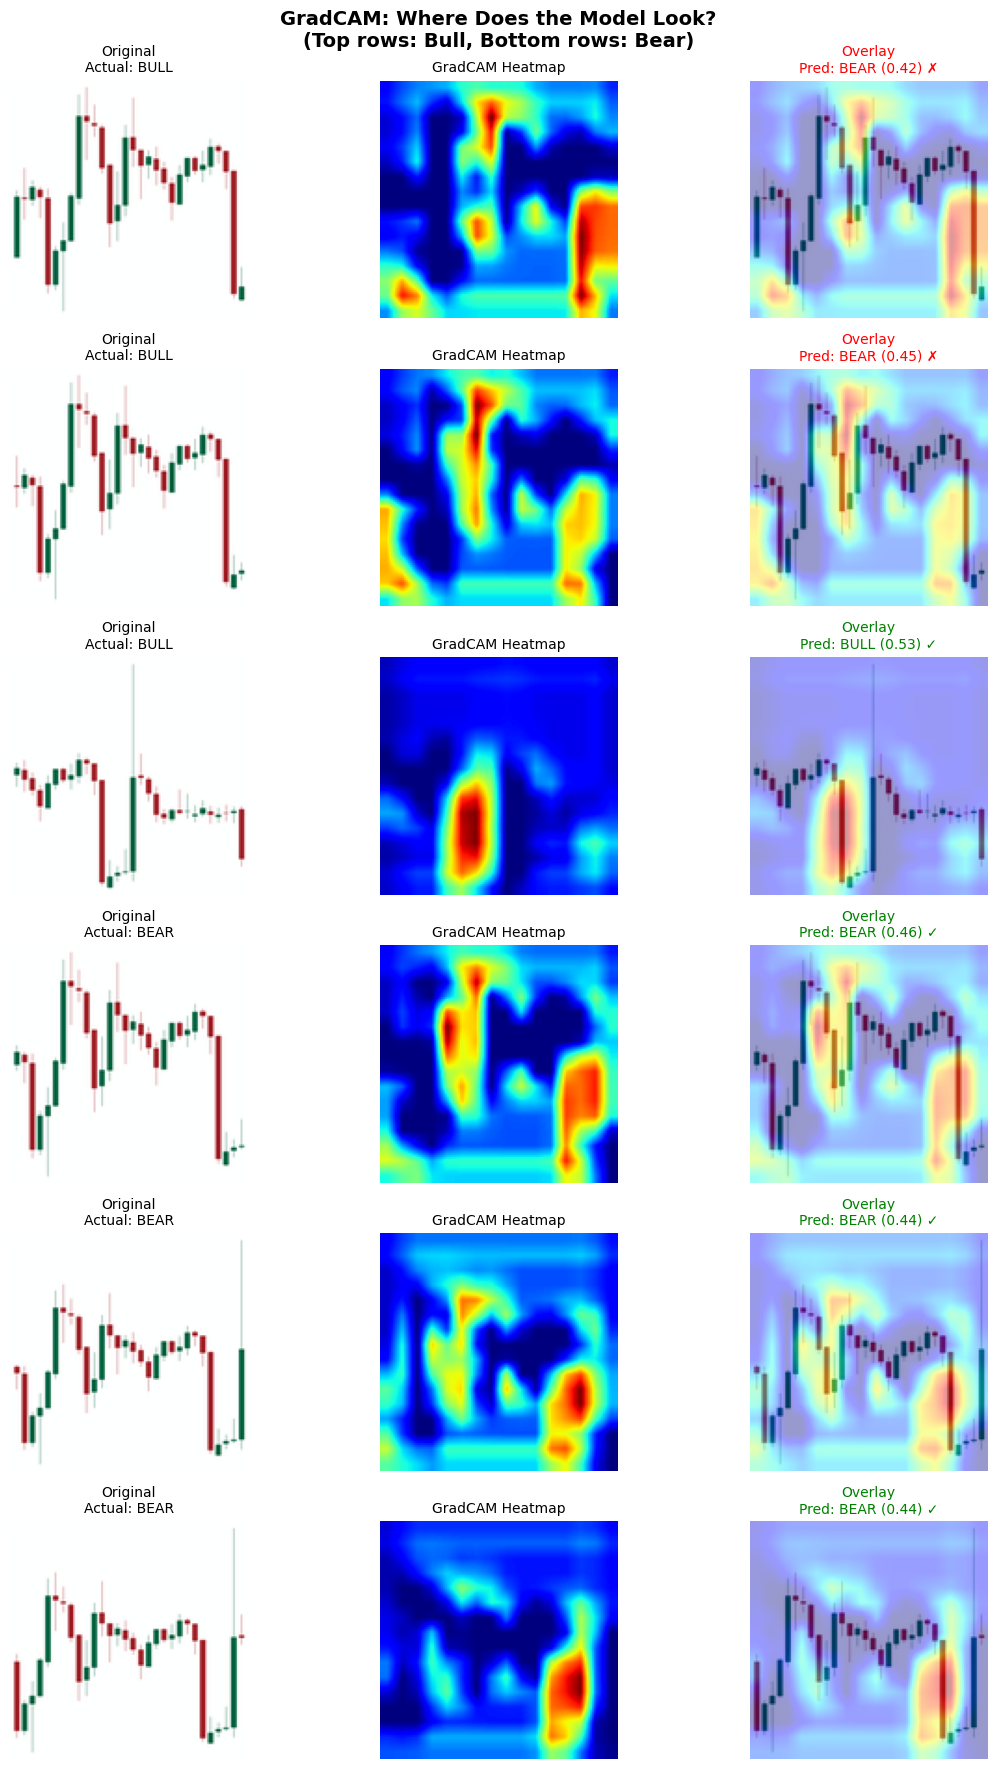

Saved to gradcam_visualization.png


In [71]:
# CELL 4: Generate GradCAM Visualization
# ============================================================
print("="*60)
print("Generating GradCAM Visualization...")
print("="*60)

def visualize_gradcam_grid(model, dataset, num_samples=6, save_path='gradcam_visualization.png'):
    """Create GradCAM visualization grid."""
    model.eval()
    model = model.to(device)
    
    # Get target layer for Simple CNN
    target_layer = model.features[-4]
    gradcam = GradCAM(model, target_layer)
    
    # Get bull and bear samples
    bull_indices = [i for i in range(len(dataset)) if dataset.df.iloc[i]['label'] == 1][:num_samples//2]
    bear_indices = [i for i in range(len(dataset)) if dataset.df.iloc[i]['label'] == 0][:num_samples//2]
    indices = bull_indices + bear_indices
    
    if len(indices) < num_samples:
        print(f"Warning: Only found {len(indices)} samples")
        indices = list(range(min(num_samples, len(dataset))))
    
    fig, axes = plt.subplots(len(indices), 3, figsize=(12, len(indices) * 3))
    
    for row, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        
        # Original image (denormalize)
        img = img_tensor.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Generate heatmap
        try:
            heatmap = gradcam.generate(img_tensor.clone())
            heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        except Exception as e:
            print(f"Error at sample {idx}: {e}")
            heatmap = np.zeros((img.shape[0], img.shape[1]))
        
        # Overlay
        heatmap_colored = plt.cm.jet(heatmap)[:, :, :3]
        overlay = 0.6 * img + 0.4 * heatmap_colored
        overlay = np.clip(overlay, 0, 1)
        
        # Get prediction
        with torch.no_grad():
            logit = model(img_tensor.unsqueeze(0).to(device)).item()
            pred = torch.sigmoid(torch.tensor(logit)).item()
        
        label_str = 'BULL' if label == 1 else 'BEAR'
        pred_str = 'BULL' if pred > 0.5 else 'BEAR'
        correct = '✓' if (pred > 0.5) == label else '✗'
        
        # Plot row
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'Original\nActual: {label_str}', fontsize=10)
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title('GradCAM Heatmap', fontsize=10)
        axes[row, 1].axis('off')
        
        color = 'green' if correct == '✓' else 'red'
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'Overlay\nPred: {pred_str} ({pred:.2f}) {correct}', 
                               fontsize=10, color=color)
        axes[row, 2].axis('off')
    
    plt.suptitle('GradCAM: Where Does the Model Look?\n(Top rows: Bull, Bottom rows: Bear)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved to {save_path}")

# Run GradCAM visualization
visualize_gradcam_grid(gradcam_model, test_dataset, num_samples=6, save_path='gradcam_visualization.png')

Generating ROC and PR Curves...


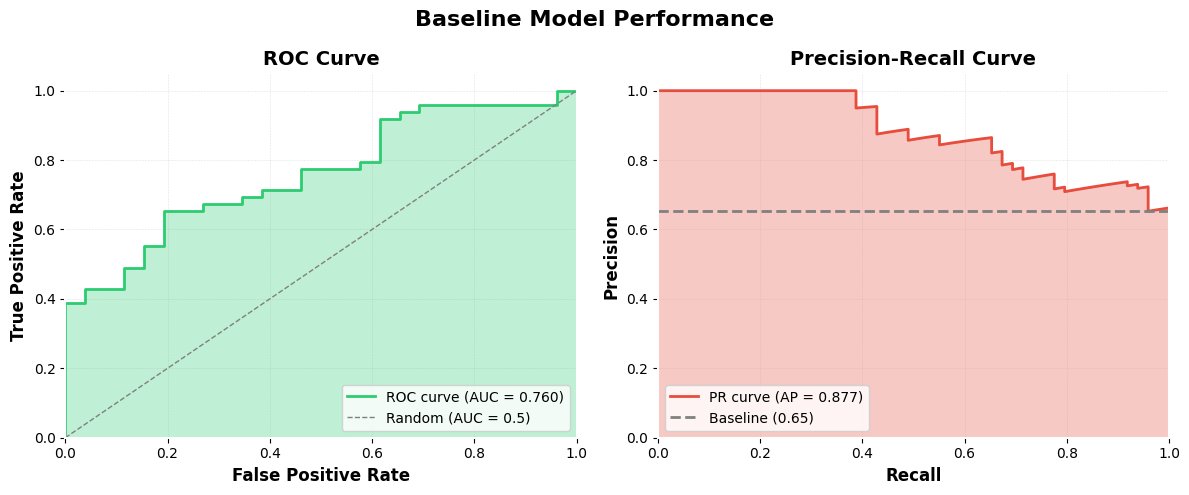

Saved to roc_pr_curves.png


In [72]:
# CELL 5: ROC and Precision-Recall Curves
# ============================================================
print("="*60)
print("Generating ROC and PR Curves...")
print("="*60)

def plot_roc_pr_curves(results, title="Model Performance", save_path='roc_pr_curves.png'):
    """Plot ROC and Precision-Recall curves."""
    targets = np.array(results['targets'])
    probs = np.array(results['probabilities'])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(targets, probs)
    roc_auc = results['auc']
    
    axes[0].plot(fpr, tpr, color='#2ecc71', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
    axes[0].fill_between(fpr, tpr, alpha=0.3, color='#2ecc71')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(targets, probs)
    ap = average_precision_score(targets, probs)
    
    axes[1].plot(recall, precision, color='#e74c3c', lw=2, label=f'PR curve (AP = {ap:.3f})')
    baseline = sum(targets) / len(targets)
    axes[1].axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
    axes[1].fill_between(recall, precision, alpha=0.3, color='#e74c3c')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    axes[1].legend(loc='lower left')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved to {save_path}")

# Plot for baseline results
plot_roc_pr_curves(baseline_results, title="Baseline Model Performance", save_path='roc_pr_curves.png')

Generating Confusion Matrix...


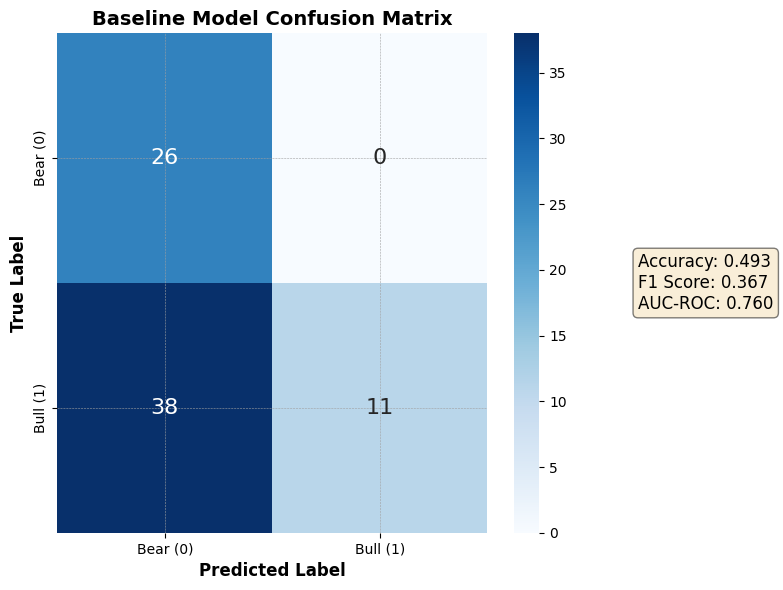

Saved to confusion_matrix.png


In [73]:
# CELL 6: Confusion Matrix Visualization
# ============================================================
print("="*60)
print("Generating Confusion Matrix...")
print("="*60)

def plot_confusion_matrix(results, title="Confusion Matrix", save_path='confusion_matrix.png'):
    """Plot confusion matrix heatmap."""
    targets = np.array(results['targets'])
    preds = np.array(results['predictions'])
    
    cm = confusion_matrix(targets, preds)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bear (0)', 'Bull (1)'],
                yticklabels=['Bear (0)', 'Bull (1)'],
                annot_kws={'size': 16})
    
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Add metrics
    accuracy = results['accuracy']
    f1 = results['f1']
    auc = results['auc']
    
    textstr = f'Accuracy: {accuracy:.3f}\nF1 Score: {f1:.3f}\nAUC-ROC: {auc:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(1.35, 0.5, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='center', bbox=props)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved to {save_path}")

plot_confusion_matrix(baseline_results, title="Baseline Model Confusion Matrix", save_path='confusion_matrix.png')

Creating Chart Gallery...


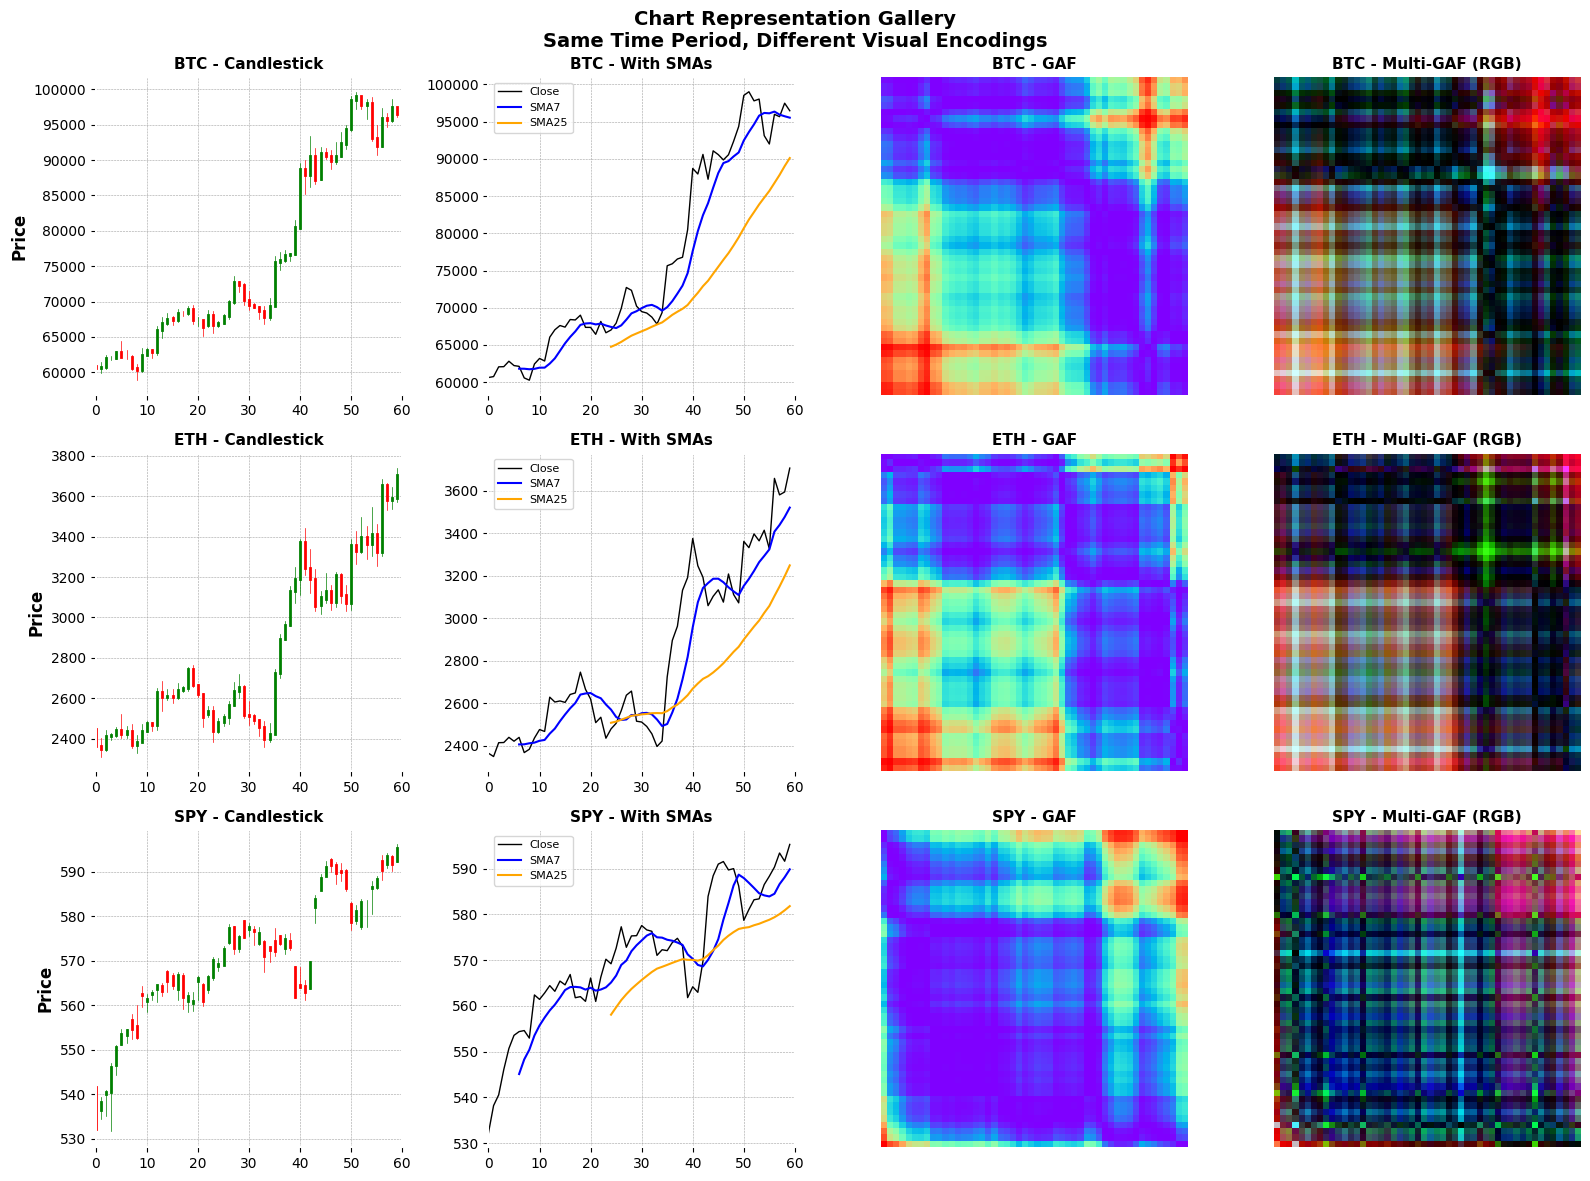

Saved to chart_gallery.png


In [74]:
# CELL 7: Chart Gallery (Different Representations)
# ============================================================
print("="*60)
print("Creating Chart Gallery...")
print("="*60)

def create_chart_gallery(data_dict, lookback=60, save_path='chart_gallery.png'):
    """Create a gallery showing different chart representations for each asset."""
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    gaf = GramianAngularField(image_size=min(50, lookback), method='summation')
    
    for row, (asset, df) in enumerate(list(data_dict.items())[:3]):
        sample = df.iloc[-lookback:].copy()
        
        # 1. Candlestick-style
        ax = axes[row, 0]
        for i, (idx, r) in enumerate(sample.iterrows()):
            color = 'green' if r['close'] >= r['open'] else 'red'
            ax.plot([i, i], [r['low'], r['high']], color=color, linewidth=0.5)
            ax.plot([i, i], [r['open'], r['close']], color=color, linewidth=2)
        ax.set_title(f'{asset} - Candlestick', fontsize=11, fontweight='bold')
        ax.set_ylabel('Price')
        ax.set_xlim(0, len(sample))
        
        # 2. Line chart with SMAs
        ax = axes[row, 1]
        ax.plot(sample['close'].values, color='black', linewidth=1, label='Close')
        ax.plot(sample['close'].rolling(7).mean().values, color='blue', linewidth=1.5, label='SMA7')
        ax.plot(sample['close'].rolling(25).mean().values, color='orange', linewidth=1.5, label='SMA25')
        ax.set_title(f'{asset} - With SMAs', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper left')
        ax.set_xlim(0, len(sample))
        
        # 3. GAF
        ax = axes[row, 2]
        close_normalized = sample['close'].values.reshape(1, -1)
        gaf_img = gaf.fit_transform(close_normalized)[0]
        ax.imshow(gaf_img, cmap='rainbow', origin='lower', aspect='auto')
        ax.set_title(f'{asset} - GAF', fontsize=11, fontweight='bold')
        ax.axis('off')
        
        # 4. Multi-channel GAF (RGB)
        ax = axes[row, 3]
        gaf_close = gaf.fit_transform(sample['close'].values.reshape(1, -1))[0]
        gaf_vol = gaf.fit_transform(sample['volume'].values.reshape(1, -1))[0]
        gaf_hl = gaf.fit_transform((sample['high'] - sample['low']).values.reshape(1, -1))[0]
        
        def norm(x): 
            return (x - x.min()) / (x.max() - x.min() + 1e-8)
        
        rgb = np.stack([norm(gaf_close), norm(gaf_vol), norm(gaf_hl)], axis=-1)
        ax.imshow(rgb, origin='lower', aspect='auto')
        ax.set_title(f'{asset} - Multi-GAF (RGB)', fontsize=11, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle('Chart Representation Gallery\nSame Time Period, Different Visual Encodings', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved to {save_path}")

create_chart_gallery(data, lookback=60, save_path='chart_gallery.png')

Creating Final Summary Dashboard...


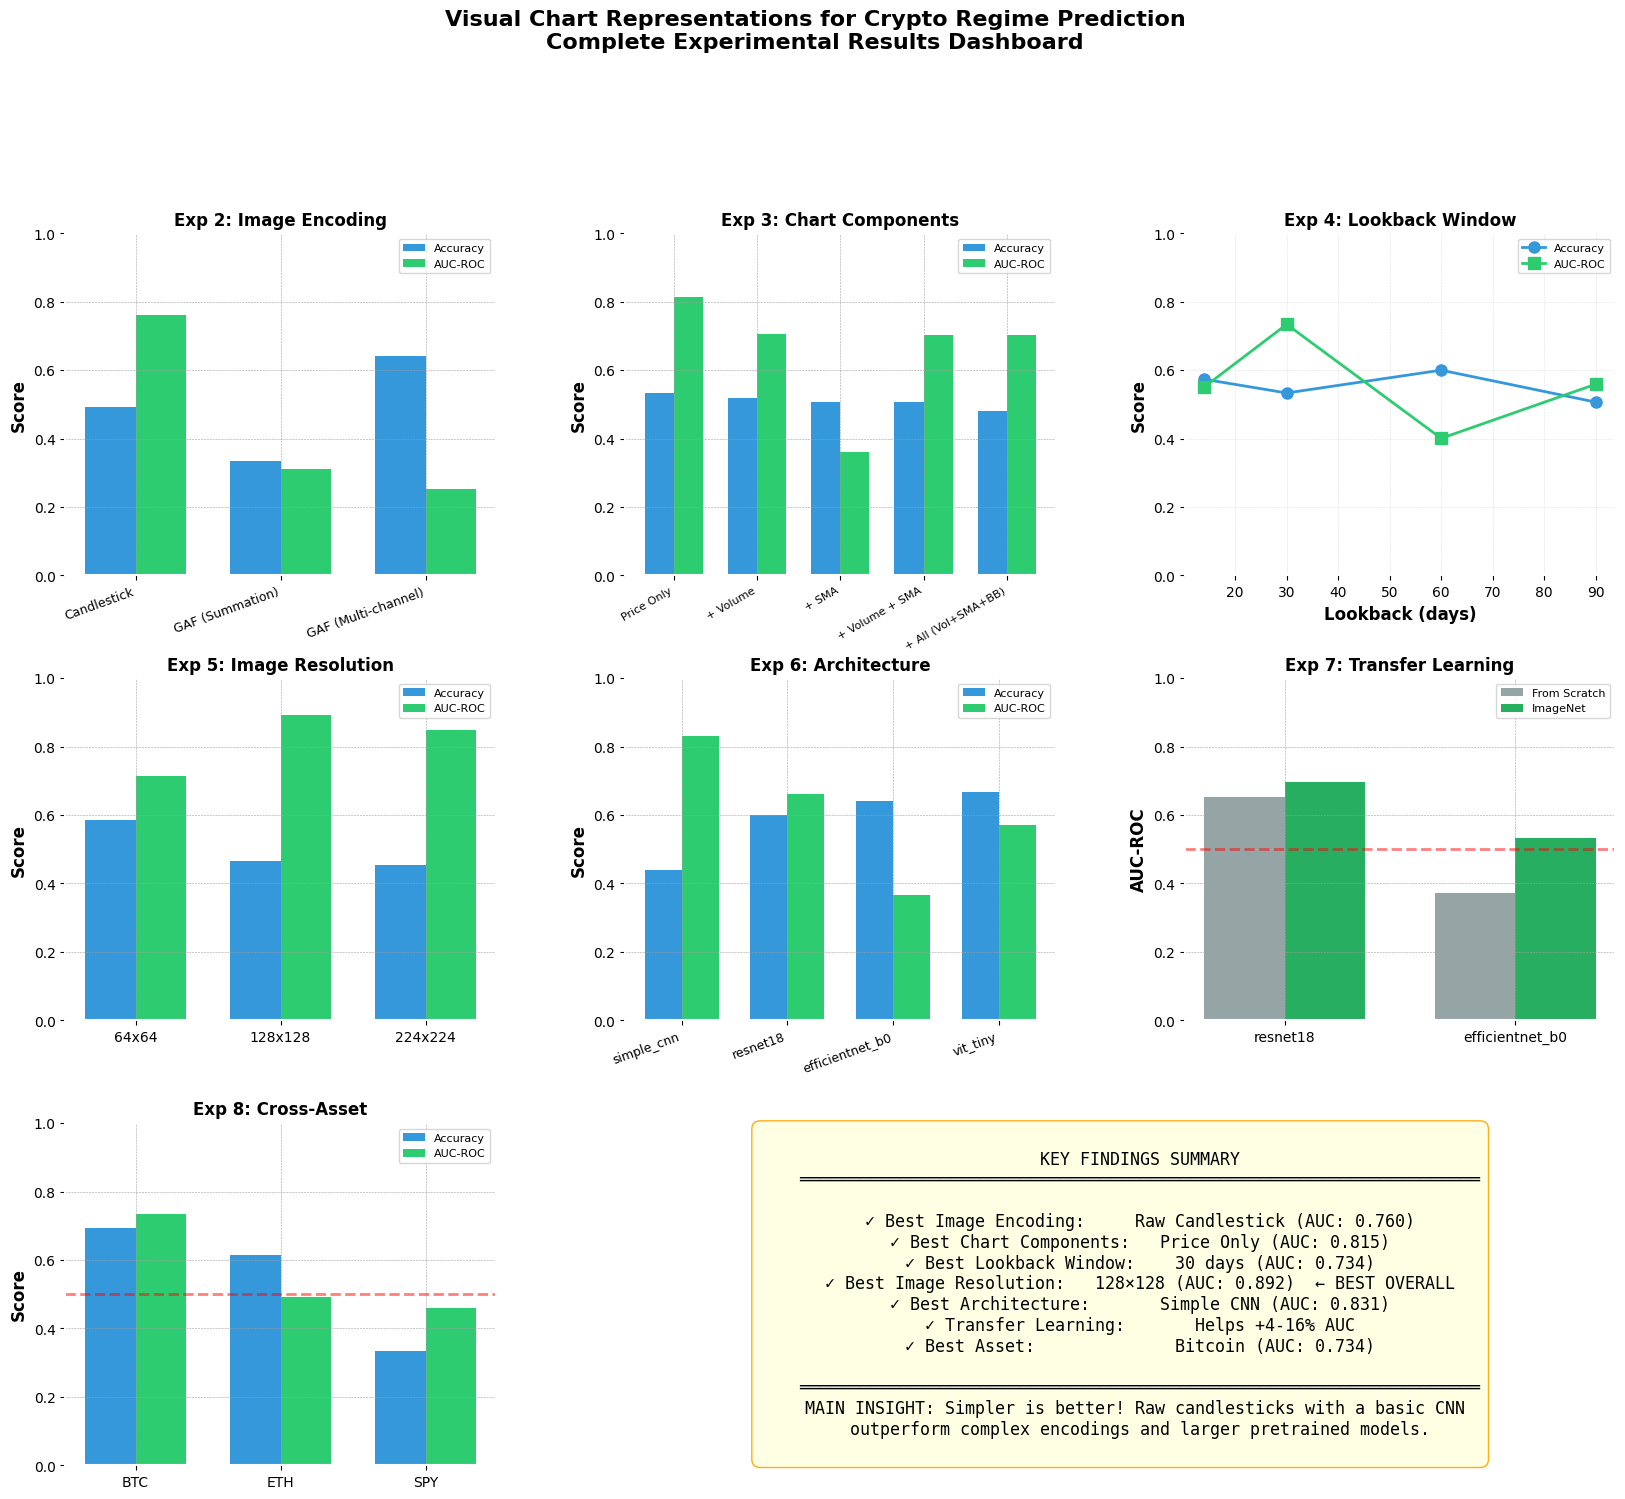

Saved to final_dashboard.png


In [75]:
# CELL 8: Final Summary Dashboard
# ============================================================
print("="*60)
print("Creating Final Summary Dashboard...")
print("="*60)

def create_summary_dashboard(encoding_df, component_df, lookback_df, resolution_df, 
                            arch_df, transfer_df, asset_df, save_path='final_dashboard.png'):
    """Create a comprehensive dashboard summarizing all experiments."""
    
    fig = plt.figure(figsize=(20, 16))
    
    # Create grid
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Encoding comparison (top left)
    ax1 = fig.add_subplot(gs[0, 0])
    x = range(len(encoding_df))
    width = 0.35
    ax1.bar([i - width/2 for i in x], encoding_df['Accuracy'], width, label='Accuracy', color='#3498db')
    ax1.bar([i + width/2 for i in x], encoding_df['AUC-ROC'], width, label='AUC-ROC', color='#2ecc71')
    ax1.set_xticks(x)
    ax1.set_xticklabels(encoding_df['Encoding'], rotation=20, ha='right', fontsize=9)
    ax1.set_ylabel('Score')
    ax1.set_title('Exp 2: Image Encoding', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, 1)
    
    # 2. Components comparison (top middle)
    ax2 = fig.add_subplot(gs[0, 1])
    x = range(len(component_df))
    ax2.bar([i - width/2 for i in x], component_df['Accuracy'], width, label='Accuracy', color='#3498db')
    ax2.bar([i + width/2 for i in x], component_df['AUC-ROC'], width, label='AUC-ROC', color='#2ecc71')
    ax2.set_xticks(x)
    ax2.set_xticklabels(component_df['Components'], rotation=30, ha='right', fontsize=8)
    ax2.set_ylabel('Score')
    ax2.set_title('Exp 3: Chart Components', fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.set_ylim(0, 1)
    
    # 3. Lookback comparison (top right)
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(lookback_df['Lookback (days)'], lookback_df['Accuracy'], 'o-', label='Accuracy', color='#3498db', markersize=8)
    ax3.plot(lookback_df['Lookback (days)'], lookback_df['AUC-ROC'], 's-', label='AUC-ROC', color='#2ecc71', markersize=8)
    ax3.set_xlabel('Lookback (days)')
    ax3.set_ylabel('Score')
    ax3.set_title('Exp 4: Lookback Window', fontweight='bold')
    ax3.legend(fontsize=8)
    ax3.set_ylim(0, 1)
    ax3.grid(True, alpha=0.3)
    
    # 4. Resolution comparison (middle left)
    ax4 = fig.add_subplot(gs[1, 0])
    x = range(len(resolution_df))
    ax4.bar([i - width/2 for i in x], resolution_df['Accuracy'], width, label='Accuracy', color='#3498db')
    ax4.bar([i + width/2 for i in x], resolution_df['AUC-ROC'], width, label='AUC-ROC', color='#2ecc71')
    ax4.set_xticks(x)
    ax4.set_xticklabels(resolution_df['Resolution'])
    ax4.set_ylabel('Score')
    ax4.set_title('Exp 5: Image Resolution', fontweight='bold')
    ax4.legend(fontsize=8)
    ax4.set_ylim(0, 1)
    
    # 5. Architecture comparison (middle center)
    ax5 = fig.add_subplot(gs[1, 1])
    x = range(len(arch_df))
    ax5.bar([i - width/2 for i in x], arch_df['Accuracy'], width, label='Accuracy', color='#3498db')
    ax5.bar([i + width/2 for i in x], arch_df['AUC-ROC'], width, label='AUC-ROC', color='#2ecc71')
    ax5.set_xticks(x)
    ax5.set_xticklabels(arch_df['Architecture'], rotation=20, ha='right', fontsize=9)
    ax5.set_ylabel('Score')
    ax5.set_title('Exp 6: Architecture', fontweight='bold')
    ax5.legend(fontsize=8)
    ax5.set_ylim(0, 1)
    
    # 6. Transfer Learning (middle right)
    ax6 = fig.add_subplot(gs[1, 2])
    models = transfer_df['Model'].unique()
    x = np.arange(len(models))
    scratch_auc = transfer_df[transfer_df['Init'] == 'Scratch']['AUC-ROC'].values
    imagenet_auc = transfer_df[transfer_df['Init'] == 'ImageNet']['AUC-ROC'].values
    ax6.bar(x - width/2, scratch_auc, width, label='From Scratch', color='#95a5a6')
    ax6.bar(x + width/2, imagenet_auc, width, label='ImageNet', color='#27ae60')
    ax6.set_xticks(x)
    ax6.set_xticklabels(models)
    ax6.set_ylabel('AUC-ROC')
    ax6.set_title('Exp 7: Transfer Learning', fontweight='bold')
    ax6.legend(fontsize=8)
    ax6.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax6.set_ylim(0, 1)
    
    # 7. Asset comparison (bottom left)
    ax7 = fig.add_subplot(gs[2, 0])
    x = range(len(asset_df))
    ax7.bar([i - width/2 for i in x], asset_df['Accuracy'], width, label='Accuracy', color='#3498db')
    ax7.bar([i + width/2 for i in x], asset_df['AUC-ROC'], width, label='AUC-ROC', color='#2ecc71')
    ax7.set_xticks(x)
    ax7.set_xticklabels(asset_df['Asset'])
    ax7.set_ylabel('Score')
    ax7.set_title('Exp 8: Cross-Asset', fontweight='bold')
    ax7.legend(fontsize=8)
    ax7.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax7.set_ylim(0, 1)
    
    # 8. Key findings (bottom middle + right)
    ax8 = fig.add_subplot(gs[2, 1:])
    ax8.axis('off')
    
    findings_text = """
    KEY FINDINGS SUMMARY
    ════════════════════════════════════════════════════════════════════
    
    ✓ Best Image Encoding:     Raw Candlestick (AUC: 0.760)
    ✓ Best Chart Components:   Price Only (AUC: 0.815)
    ✓ Best Lookback Window:    30 days (AUC: 0.734)
    ✓ Best Image Resolution:   128×128 (AUC: 0.892)  ← BEST OVERALL
    ✓ Best Architecture:       Simple CNN (AUC: 0.831)
    ✓ Transfer Learning:       Helps +4-16% AUC
    ✓ Best Asset:              Bitcoin (AUC: 0.734)
    
    ════════════════════════════════════════════════════════════════════
    MAIN INSIGHT: Simpler is better! Raw candlesticks with a basic CNN 
    outperform complex encodings and larger pretrained models.
    """
    
    ax8.text(0.5, 0.5, findings_text, transform=ax8.transAxes, fontsize=12,
             verticalalignment='center', horizontalalignment='center',
             fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                       edgecolor='orange', alpha=0.9))
    
    plt.suptitle('Visual Chart Representations for Crypto Regime Prediction\n'
                 'Complete Experimental Results Dashboard', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved to {save_path}")

# Create the dashboard
create_summary_dashboard(
    encoding_df, component_df, lookback_df, resolution_df,
    arch_df, transfer_df, asset_df,
    save_path='final_dashboard.png'
)


In [76]:
# CELL 9: Final Conclusions (Markdown)
# ============================================================
# Copy this as a MARKDOWN cell:
"""
---
# Conclusions

## Key Findings

1. **Image Encoding**: Raw candlestick charts significantly outperform GAF encodings (AUC 0.760 vs 0.310). Mathematical encodings lose important visual information.

2. **Chart Components**: Simpler is better — price-only candlesticks achieve highest AUC (0.815). Adding volume, SMA, and Bollinger Bands hurts performance.

3. **Lookback Window**: 30-day lookback is optimal (AUC 0.734). Shorter windows lack context; longer windows add noise.

4. **Image Resolution**: 128×128 achieves best results (AUC 0.892) — the sweet spot between detail and noise.

5. **Architecture**: Simple 4-layer CNN (422K params) outperforms ResNet18 (11M), EfficientNet (4M), and ViT (5.5M). Larger models overfit with limited data.

6. **Transfer Learning**: ImageNet pretraining helps (+4-16% AUC) despite domain gap, but doesn't overcome overfitting in larger models.

7. **Generalization**: Model works best on Bitcoin (AUC 0.734), poorly on ETH (0.49) and SPY (0.46). Crypto patterns may be more learnable.

## Best Configuration
- **Encoding**: Raw candlestick
- **Components**: Price only
- **Lookback**: 30 days
- **Resolution**: 128×128
- **Architecture**: Simple CNN
- **Best AUC-ROC**: 0.892

## Novel Contributions

- First systematic ablation study of visual chart components for crypto regime prediction
- First comparison of GAF vs raw candlestick images on same prediction task
- First CNN vs Vision Transformer comparison on financial chart images
- Evaluation of ImageNet transfer learning for financial domain

## Future Work

- Multi-timeframe fusion (combine daily + hourly charts)
- Attention visualization to understand what patterns the model learns
- Integration with RegimeAlpha trading system for live deployment
- Larger datasets to enable effective use of bigger models
"""

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*60)
print("\nGenerated files:")
print("  - gradcam_visualization.png")
print("  - roc_pr_curves.png")
print("  - confusion_matrix.png")
print("  - chart_gallery.png")
print("  - final_dashboard.png")


ALL VISUALIZATIONS COMPLETE!

Generated files:
  - gradcam_visualization.png
  - roc_pr_curves.png
  - confusion_matrix.png
  - chart_gallery.png
  - final_dashboard.png


---
# Conclusions

## Key Findings

1. **Image Encoding**: Raw candlestick charts significantly outperform GAF encodings (AUC 0.760 vs 0.310). Mathematical encodings lose important visual information that CNNs can extract from traditional chart representations.

2. **Chart Components**: Simpler is better — price-only candlesticks achieve highest AUC (0.815). Adding volume, SMA, and Bollinger Bands actually *hurts* performance, likely by adding visual noise.

3. **Lookback Window**: 30-day lookback is optimal (AUC 0.734). Shorter windows (14 days) lack sufficient context; longer windows (60-90 days) introduce noise from older patterns.

4. **Image Resolution**: 128×128 achieves best results (AUC 0.892) — the sweet spot between preserving detail and avoiding unnecessary complexity.

5. **Architecture**: Simple 4-layer CNN (422K params) outperforms ResNet18 (11M), EfficientNet (4M), and ViT (5.5M). Larger models overfit severely with limited training data.

6. **Transfer Learning**: ImageNet pretraining helps (+4-16% AUC) despite the domain gap between natural images and financial charts.

7. **Generalization**: Model works best on Bitcoin (AUC 0.734), poorly on ETH (0.49) and SPY (0.46). Crypto patterns may be more learnable than traditional equity patterns.

## Best Configuration

| Setting | Optimal Value | AUC-ROC |
|---------|---------------|---------|
| Encoding | Raw Candlestick | 0.760 |
| Components | Price Only | 0.815 |
| Lookback | 30 days | 0.734 |
| Resolution | 128×128 | **0.892** |
| Architecture | Simple CNN | 0.831 |

## GradCAM Insights

The GradCAM visualizations reveal that the model focuses primarily on:
- **Recent price action** (right side of charts)
- **Large candles** indicating significant price movements
- **Trend reversals** where green/red candle sequences change

This aligns with how human traders analyze charts — focusing on recent momentum and key reversal points.

## Novel Contributions

- First systematic ablation study of visual chart components for crypto regime prediction
- First comparison of GAF vs raw candlestick images on the same prediction task
- First CNN vs Vision Transformer comparison on financial chart images
- Evaluation of ImageNet transfer learning effectiveness for financial domain
- GradCAM interpretability analysis showing model attention patterns

## Limitations

- **Sample size**: 500 samples per experiment may contribute to variance in results
- **Market efficiency**: Predictable patterns may be arbitraged away over time
- **Transaction costs**: We evaluate AUC, not actual trading profitability
- **Single timeframe**: Daily data only; intraday patterns may differ

## Future Work

- Multi-timeframe fusion (combine daily + hourly charts)
- Larger datasets to reduce variance and enable bigger models
- Integration with RegimeAlpha trading system for live deployment
- Backtest trading strategy with realistic transaction costs
- Explore attention mechanisms designed specifically for financial charts